In [1]:
import pandas as pd
import yfinance as yf
from datetime import date
from yfetch import get_stock_history
from time import sleep

def temperature(series):
    series = series.dropna()
    if len(series) == 0:
        return None
    return (series <= series.iloc[-1]).mean()

def run(symbol, *extra_expiries):
  history = get_stock_history(symbol, interval='1d', cache_days=2)
  print(f'{symbol} ${history["Close"].iloc[-1]:.2f}')
  sleep(1)  # to avoid hitting yfinance rate limits
  ticker = yf.Ticker(symbol)
  all_expiries = sorted(set(ticker.options) | set(extra_expiries))
  rows = []
  for expiry in all_expiries:
    calendar_days = (date.fromisoformat(expiry) - date.today()).days
    weeks = round(calendar_days / 7)
    if weeks < 1:
        continue
    sma_days = weeks * 5
    sma = history['Close'].rolling(window=sma_days).mean()
    sma_dist = history.Close / sma - 1
    T = temperature(sma_dist)
    P20 = sma.iloc[-1] * (1 + sma_dist.quantile(0.20))
    mean_change = history['Close'].pct_change(periods=sma_days).mean()
    rows.append({
        'expiry': expiry,
        'days': calendar_days,
        'SMA(d)': sma_days,
        'SMA': sma.iloc[-1],
        'dist': sma_dist.iloc[-1],
        'T': T,
        'P20': P20,
        'change': mean_change, # mean stock change for that SMA period
    })

  df = pd.DataFrame(rows)
  if df.empty:
    print(f"{symbol} above all option SMAs!")
    return
  for col in ['dist', 'T']:
      df[col] = df[col].map('{:.2%}'.format)
  df['SMA'] = df['SMA'].map('${:.2f}'.format)
  df['change'] = df['change'].map('{:.2%}'.format)
  df['P20'] = df['P20'].map('${:.2f}'.format)
  print(df)

In [2]:
run('SPMO')

SPMO $148.73
       expiry  days  SMA(d)      SMA    dist       T      P20  change
0  2026-09-18    25      20  $148.04   0.46%  44.26%  $145.57   1.63%
1  2026-10-16    53      40  $149.59  -0.57%  30.84%  $146.52   3.41%
2  2026-12-18   116      85  $147.34   0.95%  35.70%  $145.04   7.34%
3  2027-01-15   144     105  $141.98   4.76%  53.78%  $139.64   8.88%
4  2027-04-16   235     170  $132.99  11.83%  68.14%  $132.86  14.80%


In [3]:
run('USD')

USD $84.47
       expiry  days  SMA(d)     SMA    dist       T     P20  change
0  2026-09-18    25      20  $86.36  -2.19%  34.95%  $80.13   5.78%
1  2026-10-16    53      40  $88.72  -4.79%  28.54%  $79.76  12.40%
2  2026-11-20    88      65  $93.11  -9.28%  23.43%  $81.25  20.24%
3  2027-02-19   179     130  $79.10   6.79%  40.32%  $68.96  41.83%


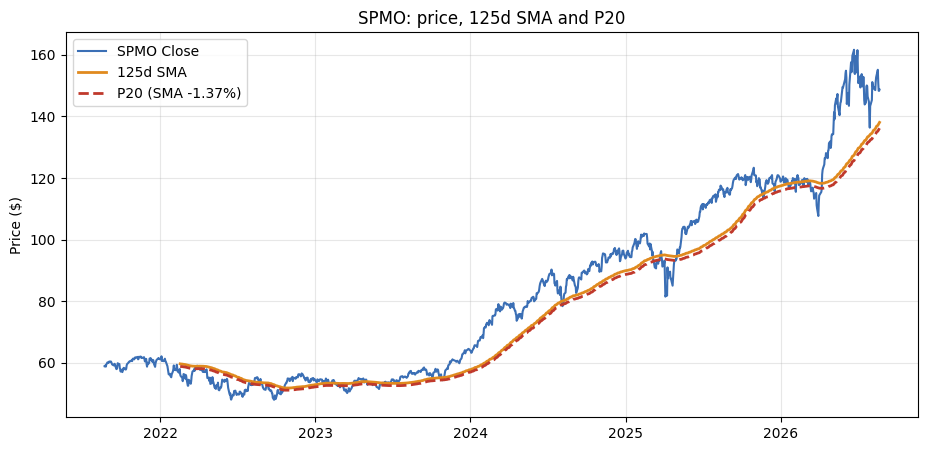

In [4]:
import matplotlib.pyplot as plt

symbol = 'SPMO'
sma_days = 125

history = get_stock_history(symbol, interval='1d', cache_days=2)
close = history['Close']
sma = close.rolling(window=sma_days).mean()
sma_dist = close / sma - 1
q20 = sma_dist.quantile(0.20)
P20 = sma * (1 + q20)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(close.index, close, color='#3b6fb5', lw=1.5, label=f'{symbol} Close')
ax.plot(sma.index, sma, color='#e08a1e', lw=2.0, label=f'{sma_days}d SMA')
ax.plot(P20.index, P20, color='#c0392b', lw=2.0, ls='--', label=f'P20 (SMA {q20:+.2%})')

ax.set_title(f'{symbol}: price, {sma_days}d SMA and P20')
ax.set_ylabel('Price ($)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
